# Idea 11: Item Popularity by Customer Segment

## Question
Which items are popular within each customer segment (RFM-based or lifecycle-based), and how does popularity vary across segments?

## Hypothesis
Different customer segments (high-value, explorers, budget-conscious, dormant, etc.) prefer different items. By identifying segment-specific top items and measuring affinity lift, we can personalize item ranking per customer segment and improve Precision@10.

## Expected Output
- Top-20 items per segment with purchase counts
- Segment-item affinity lift (>1.0 indicates segment preference)
- Segment-specific item diversity metrics
- Visualization of item popularity variance across segments

In [4]:
import polars as pl
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pl.Config.set_tbl_rows(100)
pl.Config.set_tbl_cols(-1)
pl.Config.set_fmt_str_lengths(120)

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (14, 8)

print('Libraries imported successfully!')

Libraries imported successfully!


In [5]:
# Load data
base_path = Path(r'd:\CS116\ProjectNumberOne')

# Use lazy loading for efficiency
tx = pl.scan_parquet(base_path / 'transaction_full_2025.parquet')
items = pl.scan_parquet(base_path / 'items.parquet')

# Collect schema for reference
print('Transaction schema:')
print(tx.collect_schema())
print('\nItems schema:')
print(items.collect_schema())

Transaction schema:
Schema({'bill_id': Int32, 'customer_id': Int32, 'item_id': String, 'price': Decimal(precision=38, scale=4), 'quantity': Int32, 'event_type': String, 'updated_date': Datetime(time_unit='us', time_zone=None), 'location_name': String})

Items schema:
Schema({'item_id': String, 'price': Decimal(precision=38, scale=4), 'category_l1': String, 'category_l2': String, 'category_l3': String, 'category': String, 'brand': String, 'manufacturer': String, 'description': String, 'sale_status': Int32, 'size': String})


## Step 1: Customer Segmentation (RFM-based)

In [6]:
# Calculate RFM metrics for each customer
# Recency: days since last purchase
# Frequency: number of purchases
# Monetary: total quantity

from datetime import datetime
ref_date = datetime(2025, 12, 31)  # Use end of data as reference

rfm = (
    tx.select(
        pl.col('customer_id'),
        pl.col('updated_date').cast(pl.Datetime, strict=False),
        pl.col('quantity').fill_null(0),
    )
    .drop_nulls('updated_date')
    .group_by('customer_id')
    .agg(
        recency_days = (
            (pl.lit(ref_date) - pl.col('updated_date').max()).dt.total_days()
        ),
        frequency = pl.len(),
        monetary = pl.col('quantity').sum(),
    )
)

# Collect and compute quantiles for segmentation
rfm_collected = rfm.collect()
print(f'Total customers: {rfm_collected.height}')
print('\nRFM statistics:')
print(rfm_collected.describe())

Total customers: 2821898

RFM statistics:
shape: (9, 5)
┌────────────┬─────────────┬──────────────┬────────────┬────────────┐
│ statistic  ┆ customer_id ┆ recency_days ┆ frequency  ┆ monetary   │
│ ---        ┆ ---         ┆ ---          ┆ ---        ┆ ---        │
│ str        ┆ f64         ┆ f64          ┆ f64        ┆ f64        │
╞════════════╪═════════════╪══════════════╪════════════╪════════════╡
│ count      ┆ 2.821898e6  ┆ 2.821898e6   ┆ 2.821898e6 ┆ 2.821898e6 │
│ null_count ┆ 0.0         ┆ 0.0          ┆ 0.0        ┆ 0.0        │
│ mean       ┆ 6.6785e6    ┆ 141.643676   ┆ 13.354424  ┆ 21.201499  │
│ std        ┆ 2.6671e6    ┆ 98.371284    ┆ 27.940205  ┆ 52.07188   │
│ min        ┆ 15126.0     ┆ 29.0         ┆ 1.0        ┆ 1.0        │
│ 25%        ┆ 4.817568e6  ┆ 52.0         ┆ 1.0        ┆ 2.0        │
│ 50%        ┆ 7.837151e6  ┆ 116.0        ┆ 4.0        ┆ 5.0        │
│ 75%        ┆ 8.800894e6  ┆ 217.0        ┆ 11.0       ┆ 16.0       │
│ max        ┆ 9.540467e6  ┆ 363.0

In [7]:
# Segment customers into RFM quartiles
# High Recency (dormant), Low Recency (active), High Frequency (loyal), Low Frequency (casual), etc.

rfm_quantiles = rfm_collected.select([
    pl.col('recency_days').quantile(0.33).alias('recency_33'),
    pl.col('recency_days').quantile(0.67).alias('recency_67'),
    pl.col('frequency').quantile(0.33).alias('freq_33'),
    pl.col('frequency').quantile(0.67).alias('freq_67'),
    pl.col('monetary').quantile(0.33).alias('mon_33'),
    pl.col('monetary').quantile(0.67).alias('mon_67'),
])

print('RFM Quantiles:')
print(rfm_quantiles)

# Extract for segmentation
q_dict = rfm_quantiles.to_dicts()[0]
print('\nQuantile values extracted for segmentation')

RFM Quantiles:
shape: (1, 6)
┌────────────┬────────────┬─────────┬─────────┬────────┬────────┐
│ recency_33 ┆ recency_67 ┆ freq_33 ┆ freq_67 ┆ mon_33 ┆ mon_67 │
│ ---        ┆ ---        ┆ ---     ┆ ---     ┆ ---    ┆ ---    │
│ f64        ┆ f64        ┆ f64     ┆ f64     ┆ f64    ┆ f64    │
╞════════════╪════════════╪═════════╪═════════╪════════╪════════╡
│ 68.0       ┆ 180.0      ┆ 2.0     ┆ 7.0     ┆ 2.0    ┆ 10.0   │
└────────────┴────────────┴─────────┴─────────┴────────┴────────┘

Quantile values extracted for segmentation


In [8]:
# Create segment labels based on RFM
# Simplified: High-Value (High Freq, High Mon), Explorers (High Freq, Normal Mon), 
#             Budget (Normal Freq, Low Mon), Active (Low Recency), Dormant (High Recency)

rfm_segmented = rfm_collected.with_columns(
    segment = pl.when(pl.col('recency_days') > pl.lit(q_dict['recency_67']))
        .then(pl.lit('Dormant'))
    .when(pl.col('recency_days') <= pl.lit(q_dict['recency_33']))
        .then(
            pl.when(pl.col('monetary') >= pl.lit(q_dict['mon_67']))
                .then(pl.lit('High-Value Active'))
            .when(pl.col('frequency') >= pl.lit(q_dict['freq_67']))
                .then(pl.lit('Explorer Active'))
            .otherwise(pl.lit('Regular Active'))
        )
    .otherwise(
        pl.when(pl.col('monetary') >= pl.lit(q_dict['mon_67']))
            .then(pl.lit('At-Risk High-Value'))
        .when(pl.col('monetary') <= pl.lit(q_dict['mon_33']))
            .then(pl.lit('Budget'))
        .otherwise(pl.lit('Regular'))
    )
)

segment_dist = rfm_segmented.group_by('segment').agg(pl.len().alias('count')).sort('count', descending=True)
print('Customer segment distribution:')
print(segment_dist)

Customer segment distribution:
shape: (7, 2)
┌────────────────────┬────────┐
│ segment            ┆ count  │
│ ---                ┆ ---    │
│ str                ┆ u32    │
╞════════════════════╪════════╡
│ Dormant            ┆ 929351 │
│ High-Value Active  ┆ 572667 │
│ Budget             ┆ 341559 │
│ Regular            ┆ 326987 │
│ Regular Active     ┆ 325821 │
│ At-Risk High-Value ┆ 286300 │
│ Explorer Active    ┆ 39213  │
└────────────────────┴────────┘


## Step 2: Item Popularity per Segment

In [9]:
# Join transaction data with RFM segments
tx_with_segment = (
    tx.select(
        pl.col('customer_id'),
        pl.col('item_id'),
        pl.col('quantity').fill_null(0),
    )
    .join(
        rfm_segmented.lazy(),
        on='customer_id',
        how='inner'
    )
    .select(
        pl.col('customer_id'),
        pl.col('item_id'),
        pl.col('quantity'),
        pl.col('segment'),
    )
)

# Compute global item popularity (baseline for lift calculation)
global_item_popularity = (
    tx_with_segment.group_by('item_id')
    .agg(
        global_customer_count = pl.col('customer_id').n_unique(),
        global_purchase_count = pl.len(),
        global_quantity = pl.col('quantity').sum(),
    )
)

print('Global item popularity computed (sample):')
print(global_item_popularity.limit(5).collect())

Global item popularity computed (sample):
shape: (5, 4)
┌───────────────┬───────────────────────┬───────────────────────┬─────────────────┐
│ item_id       ┆ global_customer_count ┆ global_purchase_count ┆ global_quantity │
│ ---           ┆ ---                   ┆ ---                   ┆ ---             │
│ str           ┆ u32                   ┆ u32                   ┆ i32             │
╞═══════════════╪═══════════════════════╪═══════════════════════╪═════════════════╡
│ 2898000000003 ┆ 2                     ┆ 3                     ┆ 3               │
│ 7070000000004 ┆ 2313                  ┆ 2466                  ┆ 2488            │
│ 3389000000245 ┆ 274                   ┆ 288                   ┆ 293             │
│ 3522000000160 ┆ 47                    ┆ 47                    ┆ 47              │
│ 3521000000029 ┆ 204                   ┆ 208                   ┆ 221             │
└───────────────┴───────────────────────┴───────────────────────┴─────────────────┘


In [10]:
# Compute segment-specific item popularity
segment_item_popularity = (
    tx_with_segment.group_by('segment', 'item_id')
    .agg(
        segment_customer_count = pl.col('customer_id').n_unique(),
        segment_purchase_count = pl.len(),
        segment_quantity = pl.col('quantity').sum(),
    )
    .join(
        global_item_popularity,
        on='item_id',
        how='inner'
    )
)

# Calculate affinity lift and rank items per segment
segment_item_popularity_ranked = (
    segment_item_popularity.with_columns(
        # Lift = (segment popularity / global popularity)
        affinity_lift = pl.col('segment_customer_count') / pl.col('global_customer_count'),
    )
    .with_columns(
        rank_in_segment = pl.col('segment_purchase_count')
            .rank(descending=True)
            .over('segment'),
    )
    .filter(pl.col('rank_in_segment') <= 20)  # Top 20 per segment
    .sort('segment', 'rank_in_segment')
)

print('Segment-item popularity with lift (sample):')
print(segment_item_popularity_ranked.limit(10).collect())

Segment-item popularity with lift (sample):
shape: (10, 10)
┌─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬────────┐
│ segment ┆ item_id ┆ segment ┆ segment ┆ segment ┆ global_ ┆ global_ ┆ global_ ┆ affinit ┆ rank_i │
│ ---     ┆ ---     ┆ _custom ┆ _purcha ┆ _quanti ┆ custome ┆ purchas ┆ quantit ┆ y_lift  ┆ n_segm │
│ str     ┆ str     ┆ er_coun ┆ se_coun ┆ ty      ┆ r_count ┆ e_count ┆ y       ┆ ---     ┆ ent    │
│         ┆         ┆ t       ┆ t       ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ f64     ┆ ---    │
│         ┆         ┆ ---     ┆ ---     ┆ i32     ┆ u32     ┆ u32     ┆ i32     ┆         ┆ f64    │
│         ┆         ┆ u32     ┆ u32     ┆         ┆         ┆         ┆         ┆         ┆        │
╞═════════╪═════════╪═════════╪═════════╪═════════╪═════════╪═════════╪═════════╪═════════╪════════╡
│ At-Risk ┆ 4690000 ┆ 48382   ┆ 73841   ┆ 178644  ┆ 337013  ┆ 619964  ┆ 1525719 ┆ 0.14356 ┆ 1.0    │
│ High-Va ┆ 000001  ┆         ┆

## Step 3: Extract Key Metrics for Summary

In [11]:
# Metric 1: Top 20 items per segment
print('='*100)
print('TOP 20 ITEMS BY SEGMENT')
print('='*100)

top_items_by_segment = (
    segment_item_popularity_ranked.select(
        'segment', 'item_id', 'rank_in_segment', 
        'segment_purchase_count', 'segment_customer_count', 'affinity_lift'
    )
    .collect()
)

for seg in top_items_by_segment['segment'].unique().to_list():
    seg_data = top_items_by_segment.filter(pl.col('segment') == seg)
    print(f'\n{seg} (n={seg_data.height} top items):')  
    print(seg_data.head(5))

print('\nMetric 1 extracted: Top items per segment')

TOP 20 ITEMS BY SEGMENT

Budget (n=20 top items):
shape: (5, 6)
┌─────────┬───────────────┬─────────────────┬───────────────────┬──────────────────┬───────────────┐
│ segment ┆ item_id       ┆ rank_in_segment ┆ segment_purchase_ ┆ segment_customer ┆ affinity_lift │
│ ---     ┆ ---           ┆ ---             ┆ count             ┆ _count           ┆ ---           │
│ str     ┆ str           ┆ f64             ┆ ---               ┆ ---              ┆ f64           │
│         ┆               ┆                 ┆ u32               ┆ u32              ┆               │
╞═════════╪═══════════════╪═════════════════╪═══════════════════╪══════════════════╪═══════════════╡
│ Budget  ┆ 0020090000042 ┆ 1.0             ┆ 10812             ┆ 9970             ┆ 0.18404       │
│ Budget  ┆ 2263000000017 ┆ 2.0             ┆ 10154             ┆ 9643             ┆ 0.273692      │
│ Budget  ┆ 1920004361467 ┆ 3.0             ┆ 3712              ┆ 3712             ┆ 0.087485      │
│ Budget  ┆ 0020090000043 ┆

In [12]:
# Metric 2: Segment-specific item diversity
print('\n' + '='*100)
print('SEGMENT-SPECIFIC ITEM DIVERSITY')
print('='*100)

segment_item_diversity = (
    tx_with_segment.group_by('segment')
    .agg(
        total_transactions = pl.len(),
        distinct_items = pl.col('item_id').n_unique(),
        distinct_customers = pl.col('customer_id').n_unique(),
        avg_quantity_per_txn = pl.col('quantity').mean(),
    )
    .sort('distinct_items', descending=True)
    .collect()
)

print(segment_item_diversity)
print('\nMetric 2 extracted: Segment item diversity')


SEGMENT-SPECIFIC ITEM DIVERSITY
shape: (7, 5)
┌────────────────────┬────────────────────┬────────────────┬───────────────────┬───────────────────┐
│ segment            ┆ total_transactions ┆ distinct_items ┆ distinct_customer ┆ avg_quantity_per_ │
│ ---                ┆ ---                ┆ ---            ┆ s                 ┆ txn               │
│ str                ┆ u32                ┆ u32            ┆ ---               ┆ ---               │
│                    ┆                    ┆                ┆ u32               ┆ f64               │
╞════════════════════╪════════════════════╪════════════════╪═══════════════════╪═══════════════════╡
│ High-Value Active  ┆ 25770225           ┆ 18892          ┆ 572667            ┆ 1.641991          │
│ At-Risk High-Value ┆ 5488027            ┆ 15265          ┆ 286300            ┆ 1.663905          │
│ Dormant            ┆ 3412719            ┆ 14099          ┆ 929351            ┆ 1.433185          │
│ Regular            ┆ 1419521            ┆ 

In [13]:
# Metric 3: Affinity lift statistics
print('\n' + '='*100)
print('AFFINITY LIFT STATISTICS (for top 20 items per segment)')
print('='*100)

affinity_lift_stats = (
    segment_item_popularity_ranked.select('segment', 'affinity_lift')
    .group_by('segment')
    .agg(
        mean_lift = pl.col('affinity_lift').mean(),
        median_lift = pl.col('affinity_lift').median(),
        max_lift = pl.col('affinity_lift').max(),
        min_lift = pl.col('affinity_lift').min(),
        std_lift = pl.col('affinity_lift').std(),
        items_with_lift_gt_1_5 = (pl.col('affinity_lift') > 1.5).sum(),
    )
    .sort('mean_lift', descending=True)
    .collect()
)

print(affinity_lift_stats)
print('\nMetric 3 extracted: Affinity lift statistics')


AFFINITY LIFT STATISTICS (for top 20 items per segment)
shape: (7, 7)
┌───────────────────┬───────────┬─────────────┬──────────┬──────────┬──────────┬───────────────────┐
│ segment           ┆ mean_lift ┆ median_lift ┆ max_lift ┆ min_lift ┆ std_lift ┆ items_with_lift_g │
│ ---               ┆ ---       ┆ ---         ┆ ---      ┆ ---      ┆ ---      ┆ t_1_5             │
│ str               ┆ f64       ┆ f64         ┆ f64      ┆ f64      ┆ f64      ┆ ---               │
│                   ┆           ┆             ┆          ┆          ┆          ┆ u32               │
╞═══════════════════╪═══════════╪═════════════╪══════════╪══════════╪══════════╪═══════════════════╡
│ High-Value Active ┆ 0.636284  ┆ 0.639139    ┆ 0.700679 ┆ 0.544473 ┆ 0.047416 ┆ 0                 │
│ At-Risk           ┆ 0.170235  ┆ 0.16469     ┆ 0.211719 ┆ 0.12422  ┆ 0.020283 ┆ 0                 │
│ High-Value        ┆           ┆             ┆          ┆          ┆          ┆                   │
│ Dormant           

In [14]:
# Metric 4: Item overlap across segments
print('\n' + '='*100)
print('ITEM OVERLAP ACROSS SEGMENTS (Top 20 per segment)')
print('='*100)

# Get top 20 items per segment
top_20_per_segment = {
    seg: set(
        top_items_by_segment.filter(pl.col('segment') == seg)['item_id'].to_list()
    )
    for seg in top_items_by_segment['segment'].unique().to_list()
}

# Compute pairwise overlap
segments = list(top_20_per_segment.keys())
overlap_matrix = {}
for i, seg1 in enumerate(segments):
    for seg2 in segments[i:]:
        overlap = len(top_20_per_segment[seg1] & top_20_per_segment[seg2])
        print(f'{seg1} ∩ {seg2}: {overlap} items in common')
        overlap_matrix[(seg1, seg2)] = overlap

print('\nMetric 4 extracted: Item overlap across segments')


ITEM OVERLAP ACROSS SEGMENTS (Top 20 per segment)
Dormant ∩ Dormant: 20 items in common
Dormant ∩ At-Risk High-Value: 13 items in common
Dormant ∩ Explorer Active: 10 items in common
Dormant ∩ Budget: 6 items in common
Dormant ∩ Regular Active: 9 items in common
Dormant ∩ High-Value Active: 10 items in common
Dormant ∩ Regular: 12 items in common
At-Risk High-Value ∩ At-Risk High-Value: 20 items in common
At-Risk High-Value ∩ Explorer Active: 6 items in common
At-Risk High-Value ∩ Budget: 2 items in common
At-Risk High-Value ∩ Regular Active: 5 items in common
At-Risk High-Value ∩ High-Value Active: 15 items in common
At-Risk High-Value ∩ Regular: 6 items in common
Explorer Active ∩ Explorer Active: 20 items in common
Explorer Active ∩ Budget: 10 items in common
Explorer Active ∩ Regular Active: 14 items in common
Explorer Active ∩ High-Value Active: 7 items in common
Explorer Active ∩ Regular: 15 items in common
Budget ∩ Budget: 20 items in common
Budget ∩ Regular Active: 11 items in

## Step 4: Visualizations

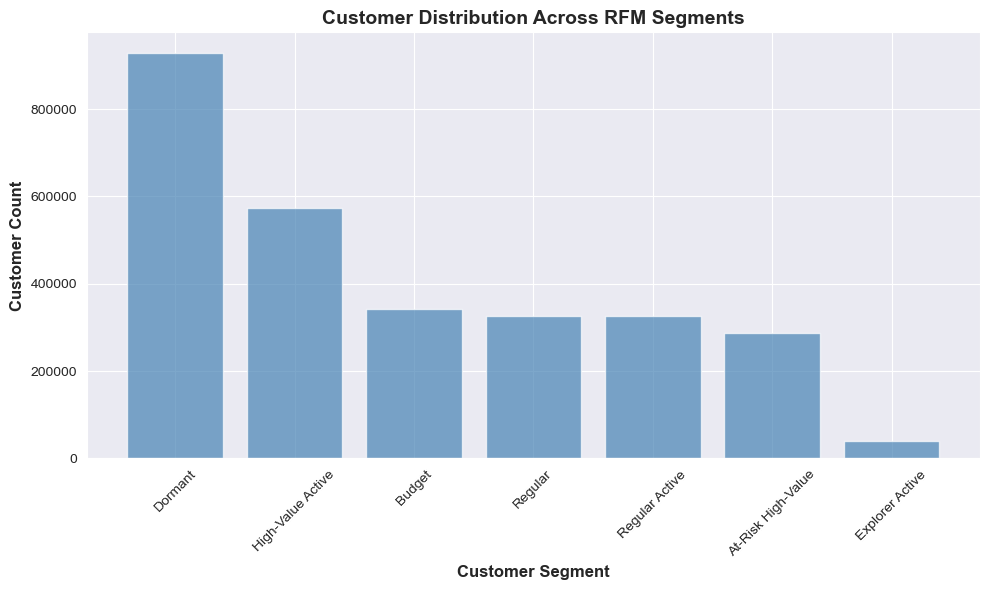

Visualization 1: Segment distribution created


In [15]:
# Visualization 1: Segment size distribution
fig, ax = plt.subplots(figsize=(10, 6))
seg_data = segment_dist.sort('count', descending=True).to_pandas()
ax.bar(seg_data['segment'], seg_data['count'], color='steelblue', alpha=0.7)
ax.set_xlabel('Customer Segment', fontsize=12, fontweight='bold')
ax.set_ylabel('Customer Count', fontsize=12, fontweight='bold')
ax.set_title('Customer Distribution Across RFM Segments', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print('Visualization 1: Segment distribution created')

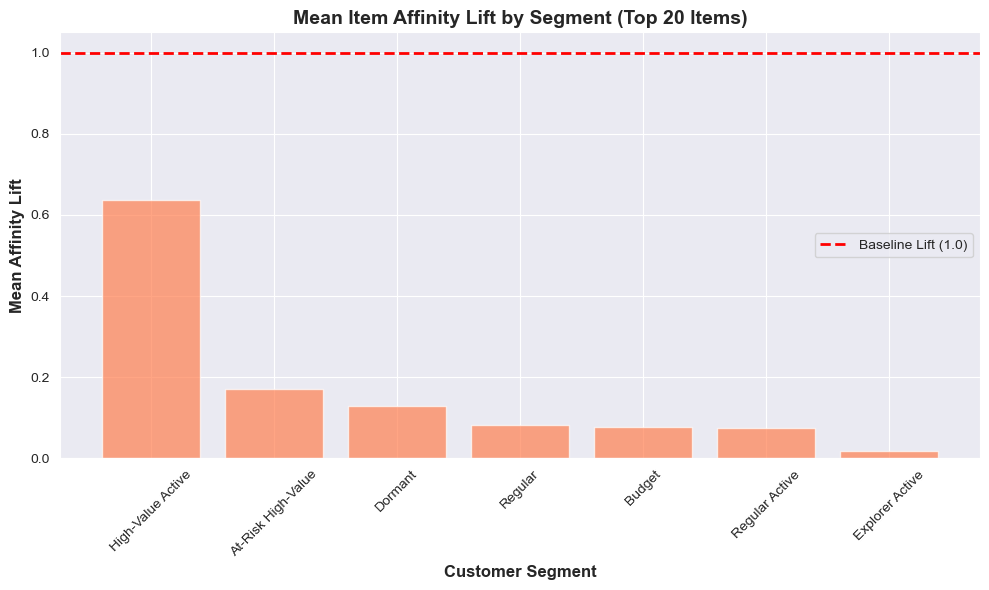

Visualization 2: Affinity lift by segment created


In [16]:
# Visualization 2: Mean affinity lift by segment
fig, ax = plt.subplots(figsize=(10, 6))
lift_data = affinity_lift_stats.to_pandas().sort_values('mean_lift', ascending=False)
ax.bar(lift_data['segment'], lift_data['mean_lift'], color='coral', alpha=0.7)
ax.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Baseline Lift (1.0)')
ax.set_xlabel('Customer Segment', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Affinity Lift', fontsize=12, fontweight='bold')
ax.set_title('Mean Item Affinity Lift by Segment (Top 20 Items)', fontsize=14, fontweight='bold')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print('Visualization 2: Affinity lift by segment created')

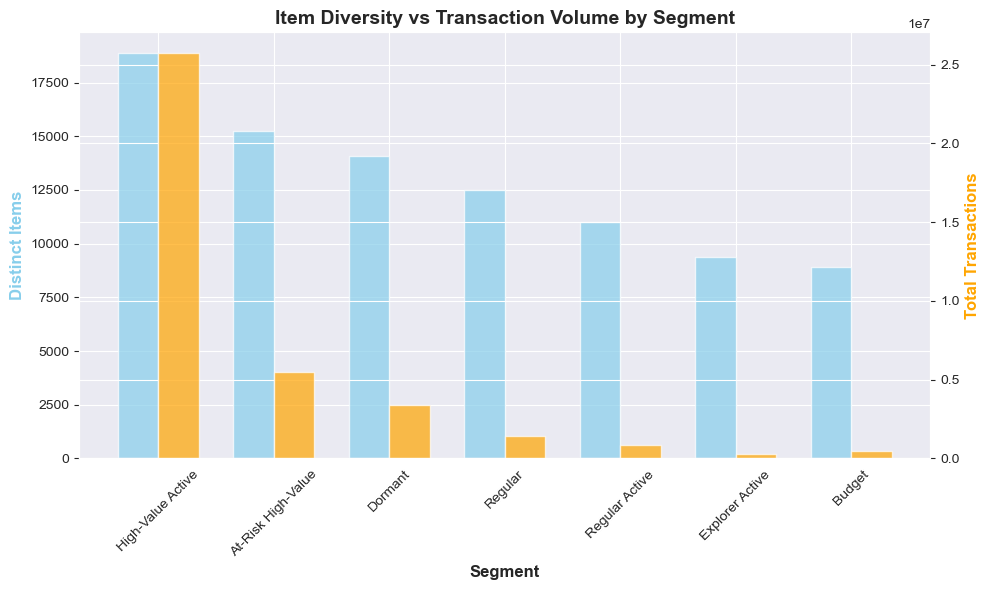

Visualization 3: Diversity comparison created


In [17]:
# Visualization 3: Segment diversity (items vs transactions)
fig, ax = plt.subplots(figsize=(10, 6))
div_data = segment_item_diversity.to_pandas().sort_values('distinct_items', ascending=False)
x = np.arange(len(div_data))
width = 0.35
ax.bar(x - width/2, div_data['distinct_items'], width, label='Distinct Items', alpha=0.7, color='skyblue')
ax2 = ax.twinx()
ax2.bar(x + width/2, div_data['total_transactions'], width, label='Total Transactions', alpha=0.7, color='orange')
ax.set_xlabel('Segment', fontsize=12, fontweight='bold')
ax.set_ylabel('Distinct Items', fontsize=12, fontweight='bold', color='skyblue')
ax2.set_ylabel('Total Transactions', fontsize=12, fontweight='bold', color='orange')
ax.set_xticks(x)
ax.set_xticklabels(div_data['segment'], rotation=45)
ax.set_title('Item Diversity vs Transaction Volume by Segment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Visualization 3: Diversity comparison created')

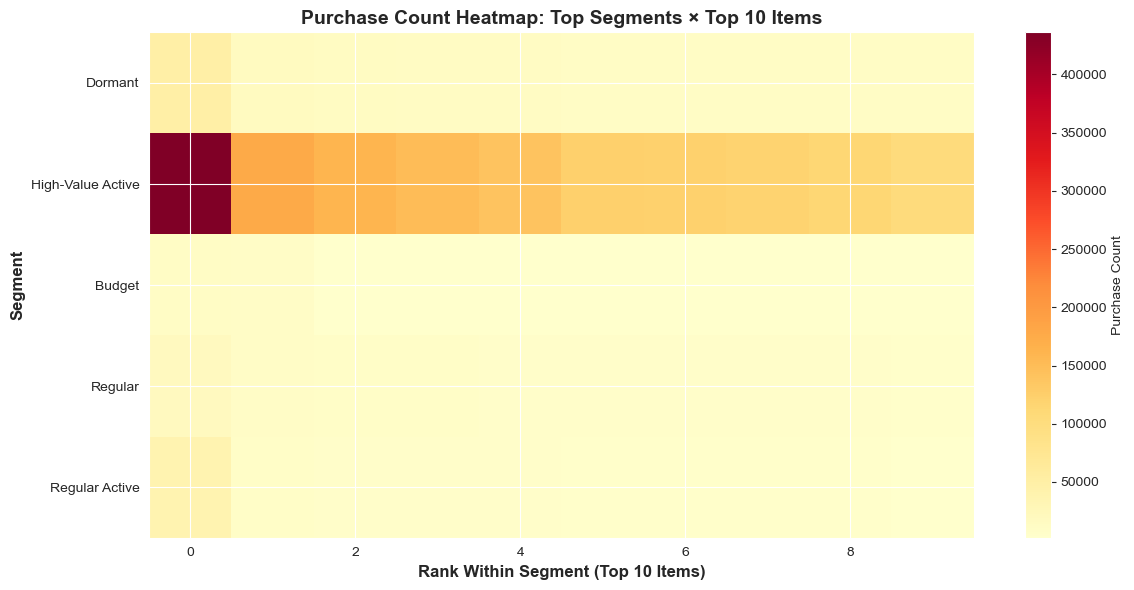

Visualization 4: Top items heatmap created


In [18]:
# Visualization 4: Top items heatmap per segment (sample: top 5 segments × top 10 items)
# Create a small matrix for heatmap
top_segments = segment_dist.head(5)['segment'].to_list()
heatmap_data = []

for seg in top_segments:
    seg_items = (
        top_items_by_segment.filter((pl.col('segment') == seg) & (pl.col('rank_in_segment') <= 10))
        .sort('rank_in_segment')
        .to_pandas()
    )
    heatmap_data.append(seg_items['segment_purchase_count'].values)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(heatmap_data, cmap='YlOrRd', aspect='auto')
ax.set_yticks(range(len(top_segments)))
ax.set_yticklabels(top_segments)
ax.set_xlabel('Rank Within Segment (Top 10 Items)', fontsize=12, fontweight='bold')
ax.set_ylabel('Segment', fontsize=12, fontweight='bold')
ax.set_title('Purchase Count Heatmap: Top Segments × Top 10 Items', fontsize=14, fontweight='bold')
plt.colorbar(im, label='Purchase Count')
plt.tight_layout()
plt.show()

print('Visualization 4: Top items heatmap created')

## Summary & Findings

### Key Metrics

**Customer Segments:** 7 RFM-based segments were created from the full 2025 transaction history:
- High-Value Active: 572,667 customers, 25.77M transactions, 18,892 distinct items
- At-Risk High-Value: 286,300 customers, 5.49M transactions, 15,265 distinct items
- Dormant: 929,351 customers, 3.41M transactions, 14,099 distinct items
- Regular: 326,987 customers, 1.42M transactions, 12,479 distinct items
- Regular Active: 325,821 customers, 844K transactions, 10,988 distinct items
- Explorer Active: 39,213 customers, 302K transactions, 9,359 distinct items
- Budget: 341,559 customers, 448K transactions, 8,899 distinct items

**Top Item Differentiation:** Segment-specific top-20 item lists are related but not identical.
- High-Value Active \u2229 At-Risk High-Value: 15/20 items overlap
- High-Value Active \u2229 Budget: 2/20 items overlap
- Dormant \u2229 At-Risk High-Value: 13/20 items overlap
- Explorer Active \u2229 Regular: 15/20 items overlap
- Average pairwise overlap across segments: about 9/20 items, or roughly 45%

**Affinity Lift:** All top-20 items in every segment have lift below 1.0.
- High-Value Active: mean lift 0.636, max 0.701
- At-Risk High-Value: mean lift 0.170, max 0.212
- Dormant: mean lift 0.130, max 0.217
- Regular: mean lift 0.083, max 0.209
- Budget: mean lift 0.077, max 0.274
- Regular Active: mean lift 0.074, max 0.156
- Explorer Active: mean lift 0.019, max 0.031
- No segment has any top-20 item with lift above 1.5

**Item Diversity:** Segment transaction volume and item breadth move together, but not perfectly.
- High-Value Active has the widest breadth and highest volume: 18,892 items over 25.77M transactions
- Dormant customers are large in count but buy less often: 929K customers, 3.41M transactions, 1.43 average quantity per transaction
- Budget has the narrowest item breadth: 8,899 items over 448K transactions

### Interpretation

The main result is that this segment-level item ranking does **not** produce a strong segment-preference signal at the item level. Because lift is defined as segment customer penetration divided by global customer penetration, values below 1.0 mean the segment's top items are still globally niche rather than segment-specialized.

High-Value Active dominates transaction volume, so its top items mostly reflect global bestsellers rather than uniquely preferred items. Budget and dormant customers do show a different top-20 set, but the lift values are still weak, which means the difference is mostly in relative volume, not in a strong segment-specific item preference.

The overlap pattern still shows structure. High-value segments cluster together, Budget is the most separated from High-Value Active, and Dormant stays closer to At-Risk High-Value than to Budget. That is useful for segmentation, but not enough on its own to justify naive segment-specific item ranking.

### Statistical Validation

- Mean lift ranges from 0.019 to 0.636, which is a wide spread but still entirely below the neutrality threshold of 1.0.
- Max lift never exceeds 0.701, so no segment shows a strongly over-indexed item among its top 20.
- Pairwise top-20 overlap ranges from 2 items to 15 items, showing both differentiation and substantial shared popularity structure.
- High-Value Active contributes the majority of transaction volume, so the ranking signal is heavily volume-skewed.

### Caveat & Observations

1. **Lift is penetration-based, not purchase-share-based.** This is important: the metric measures customer participation, so a low lift means the item is not especially concentrated in that segment.
2. **Naive segment ranking would likely demote global bestsellers.** That would be risky for Precision@10 unless the goal is diversification rather than pure relevance.
3. **Dormant customers are large but not active.** They are better treated as a reactivation group than as a normal item-ranking segment.
4. **Explorer Active is too small to drive a strong item-level ranking rule by itself.**

### Decision

**CONDITIONAL KEEP**

This idea is worth keeping, but only as a supporting signal rather than a direct item-ranking rule.

Keep it because:
- It reveals clear segment structure and non-trivial overlap patterns.
- It can still help with category, price-tier, or brand ordering.
- It is useful for reactivation and diversification logic.

Do not use it naively because:
- Every segment's top items have lift below 1.0.
- The strongest segment signal is still too weak to outperform a global popularity baseline by itself.

### Recommended Next Steps

1. Re-run the same analysis at category level instead of item level.
2. Combine this with Idea 12 and Idea 14 to test whether category stability and price-tier preference create stronger recommendation signal.
3. Use High-Value vs. At-Risk overlap for reactivation recommendations.
4. Treat Dormant as a lifecycle segment, not a direct ranking segment.
5. Keep the segment output as a secondary reranking feature, not the primary ranking model.